### AI Financial Analyst

#### Member 2

### Notebook 6 - RAG Report Generation

---

#### Objective

This notebook is the main notebook for the Generative AI part of the
project. It uses everything built in Notebooks 1 to 5 to generate the
three analyst reports for every selected company. The three reports are:

- Executive Summary
- Risk Assessment
- Investment Recommendation

We generate each report in four different ways:

- Zero-shot prompting
- Few-shot prompting
- Role prompting
- Retrieval-Augmented Generation (RAG)

Every condition gets the same structured financial numbers (from Member
1's work). The only thing that changes between conditions is whether the
model also gets retrieved text from the company's SEC filing. This way we
are only testing the effect of adding retrieved text, not the effect of
having financial numbers or not.

This notebook is not a chatbot. It just runs a fixed batch of report
generations and saves everything in one file so Member 3 can use it for
evaluation.

#### CRISP-DM Phase: Modeling

This notebook covers the Modeling phase of CRISP-DM for the Generative AI
side of the project. Member 1's MLP model covers the structured data
side. This notebook covers the generative side: combining structured data
and narrative text into four different generation methods, for three
tasks.

#### Step 1 - Importing Libraries

In [1]:
# importing libraries

import os
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import faiss
import requests

from sentence_transformers import SentenceTransformer
from openai import OpenAI
from dotenv import load_dotenv

from tqdm.auto import tqdm

print("Libraries imported.")

Libraries imported.


#### Step 2 - Loading Structured Financial Data (Member 1's Files)

We load the cleaned structured dataset, the company mapping file, and the
list of selected companies from Member 1. These give us the financial
numbers we will put into every prompt, and the full list of company-years
we need to loop through.

In [2]:
# loading member 1 outputs

processed_data = pd.read_csv("../data/processed/processed_financial_data.csv")
company_mapping = pd.read_csv("../data/processed/company_mapping.csv")
selected_companies = pd.read_csv("../data/processed/selected_companies.csv")

for df in [processed_data, company_mapping, selected_companies]:
    df.columns = df.columns.str.strip().str.lower()

processed_data["year"] = processed_data["year"].astype(str)
company_mapping["year"] = company_mapping["year"].astype(str)
company_mapping["cik"] = company_mapping["cik"].astype(str).str.strip()

print("Structured datasets loaded.")
print("Processed Financial Data :", processed_data.shape)
print("Company Mapping          :", company_mapping.shape)
print("Selected Companies       :", selected_companies.shape)

Structured datasets loaded.
Processed Financial Data : (110, 217)
Company Mapping          : (110, 5)
Selected Companies       : (22, 4)


#### Step 3 - Loading Narrative Data (from Notebooks 3 to 5)

Here we load the narrative sections file, the processed chunks, the chunk
embeddings and the FAISS index. These files let us do company-specific
search over the SEC filing text for the RAG condition.

In [3]:
# loading narrative data

narrative_df = pd.read_parquet("../data/processed/narrative_sections.parquet")
chunk_metadata = pd.read_parquet("../data/processed/chunk_metadata.parquet")

chunk_embeddings = np.load("../data/processed/chunk_embeddings.npy")
faiss_index = faiss.read_index("../data/processed/faiss_index.bin")

narrative_df["year"] = narrative_df["year"].astype(str)
chunk_metadata["year"] = chunk_metadata["year"].astype(str)

print("Narrative data loaded.")
print("Narrative Sections  :", narrative_df.shape)
print("Chunk Metadata       :", chunk_metadata.shape)
print("Chunk Embeddings     :", chunk_embeddings.shape)
print("FAISS Vectors Stored :", faiss_index.ntotal)

Narrative data loaded.
Narrative Sections  : (109, 7)
Chunk Metadata       : (10009, 8)
Chunk Embeddings     : (10009, 384)
FAISS Vectors Stored : 10009


#### Step 4 - Loading Embedding Model

We need to use the same embedding model as Notebook 5
(`all-MiniLM-L6-v2`). If we use a different model here, the query
embeddings will not match the stored chunk embeddings, and search results
will be wrong without giving any error.

In [4]:
# loading embedding model (must be same as notebook 5)

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

assert chunk_embeddings.shape[1] == embedding_model.get_sentence_embedding_dimension(), (
    "Embedding size does not match. The loaded model is not the same "
    "model used to build the stored embeddings."
)

print("Embedding model loaded and checked against stored embeddings.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded and checked against stored embeddings.


C:\Users\Rakhi\AppData\Local\Temp\ipykernel_23868\4216886575.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  assert chunk_embeddings.shape[1] == embedding_model.get_sentence_embedding_dimension(), (


#### Step 4b - Column Name Checking

We had a few problems earlier in this project where a column name was
written with different capital letters in different notebooks (for
example `section_1A` vs `section_1a`). To stop this happening again, we
made a small function that finds the real column name in the data, no
matter how it is capitalised.

In [5]:
# column name checking function

def resolve_column(df, expected_name):
    """
    Finds the real column in df that matches expected_name, ignoring
    upper/lower case and extra spaces. Gives a clear error if it finds
    zero matches or more than one match, instead of failing later with a
    confusing KeyError.
    """
    normalised_target = expected_name.strip().lower()
    matches = [
        col for col in df.columns
        if col.strip().lower() == normalised_target
    ]

    if len(matches) == 0:
        raise KeyError(
            f"No column matching '{expected_name}' found. "
            f"Available columns: {list(df.columns)}"
        )
    if len(matches) > 1:
        raise KeyError(
            f"More than one column matches '{expected_name}': {matches}. "
            "Please fix this before continuing."
        )

    return matches[0]


SECTION_1A_COL = resolve_column(narrative_df, "section_1A")
print(f"Found 'section_1A' column as: '{SECTION_1A_COL}'")

Found 'section_1A' column as: 'section_1A'


#### Step 5 - Building the Exclusion List

Notebook 3 found two problems with the data:

1. **APTV, 2017** has no narrative text at all in our EDGAR dataset, even
   though Member 1 checked and the filing exists on the live SEC website.
   We are not trying to fix this by pulling the filing again. We just
   note it as a limitation of the dataset.
2. **Five company-years** have an empty `section_1A` field (this is the
   Risk Factors section).

Member 1's structured data is complete for all 110 company-years, so the
Zero-shot, Few-shot and Role conditions do not use retrieval at all, and
are not affected by either problem. They run on the full 110 company-year
set, for all three tasks.

The two problems only affect the RAG condition, and only where retrieval
actually cannot happen:

- RAG is skipped for APTV 2017 for all three tasks, because there are no
  narrative chunks for that company-year at all.
- RAG is skipped for the Risk Assessment task only, for the five
  company-years with no Risk Factors section.

We do not use a fallback where we retrieve a different section instead
(like using MD&A when Risk Factors is missing). Doing that would change
what the RAG condition is actually grounded in, which would make the Risk
Assessment comparison less valid.

In [6]:
# building exclusion list (worked out from the data, not typed in by hand)

TASKS = ["executive_summary", "risk_assessment", "investment_recommendation"]
CONDITIONS = ["zero_shot", "few_shot", "role", "rag"]

all_company_years = set(
    zip(company_mapping["ticker"], company_mapping["year"])
)

narrative_available = set(
    zip(narrative_df["ticker"], narrative_df["year"])
)

no_narrative_at_all = all_company_years - narrative_available

empty_section_1a = set(
    zip(
        narrative_df.loc[
            narrative_df[SECTION_1A_COL].fillna("").str.strip().eq(""),
            "ticker"
        ],
        narrative_df.loc[
            narrative_df[SECTION_1A_COL].fillna("").str.strip().eq(""),
            "year"
        ],
    )
)

rag_excluded = {
    "executive_summary": no_narrative_at_all,
    "risk_assessment": no_narrative_at_all | empty_section_1a,
    "investment_recommendation": no_narrative_at_all,
}

print("=" * 60)
print("EXCLUSION LIST SUMMARY")
print("=" * 60)
print(f"Total company-years (structured)   : {len(all_company_years)}")
print(f"Company-years with no narrative    : {len(no_narrative_at_all)}")
print(f"Company-years with empty section_1A: {len(empty_section_1a)}")
print()
for task in TASKS:
    excluded_n = len(rag_excluded[task])
    print(f"RAG usable company-years for {task:<28}: {len(all_company_years) - excluded_n} / {len(all_company_years)}")
print()
print("Zero-shot, Few-shot and Role conditions run on all "
      f"{len(all_company_years)} company-years, for all {len(TASKS)} tasks, "
      "because they do not need retrieval.")

EXCLUSION LIST SUMMARY
Total company-years (structured)   : 110
Company-years with no narrative    : 1
Company-years with empty section_1A: 5

RAG usable company-years for executive_summary           : 109 / 110
RAG usable company-years for risk_assessment             : 104 / 110
RAG usable company-years for investment_recommendation   : 109 / 110

Zero-shot, Few-shot and Role conditions run on all 110 company-years, for all 3 tasks, because they do not need retrieval.


#### Step 6 - Set Up the LLM

**Model used: Google Gemini (`gemini-flash-lite-latest`)**, through
Gemini's OpenAI-compatible endpoint.

We chose Gemini's free tier because it does not need a payment method and
has enough free requests for our project (around 1,300 generations
total). We first tried a fixed model name (`gemini-2.5-flash-lite`), but
this stopped working for new accounts partway through the project. We
switched to the `-latest` alias instead, because this always points to
whichever version is currently open to new users, so it should not break
again in the same way.

Gemini gives an OpenAI-compatible endpoint, so we can use the same
`OpenAI` Python client we would use for OpenAI itself. We only had to
change the `base_url`, the API key, and the model name. This also means
if we ever need to switch provider again, we only need to change this one
cell.

**API key:** the key is loaded from a `.env` file using `python-dotenv`.
We do not type the key directly into any cell. If the key is typed into a
cell, it gets saved inside the notebook file every time we save it, and
travels with the file whenever it is shared or pushed to GitHub. This
happened twice earlier in the project, so we made sure it will not happen
again.

**Generation settings:** we use a low, fixed temperature (`0.2`), because
this is a factual financial analysis task, not creative writing. The API
does not guarantee the exact same output every time even with a fixed
temperature, so this is noted as a small limitation.

**Rate limits:** the free tier only allows a certain number of requests
per minute and per day. We add a short delay between calls to stay under
the per-minute limit, and the generation loop (Step 12) can be stopped
and started again across more than one day if needed, without losing any
finished work.

In [7]:
# setting up the LLM

# loads variables from a .env file one folder above this notebook.
# the .env file is not pushed to GitHub (see .gitignore). this keeps
# the API key out of the notebook file completely.
load_dotenv(dotenv_path=Path("../.env"))

client = OpenAI(
    api_key=os.environ.get("GEMINI_API_KEY"),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)

LLM_MODEL = "gemini-flash-lite-latest"
LLM_TEMPERATURE = 0.2
LLM_MAX_TOKENS = 700
PROMPT_VERSION = "v1"

# safety gap between calls to stay under the free tier rate limit
MIN_SECONDS_BETWEEN_CALLS = 4.5


def call_llm(prompt, system_message="You are a professional financial analyst.",
             max_tokens=None):
    """
    Sends a prompt to the LLM and gives back the response text, how long
    it took, how many tokens were used, and the finish reason. The finish
    reason tells us if the model stopped normally ("stop") or got cut off
    because it ran out of tokens ("length"). We use this later in Step 16
    to find and fix any answer that got cut off.
    """
    start_time = time.time()

    response = client.chat.completions.create(
        model=LLM_MODEL,
        temperature=LLM_TEMPERATURE,
        max_tokens=max_tokens or LLM_MAX_TOKENS,
        messages=[
            {"role": "system", "content": system_message},
            {"role": "user", "content": prompt},
        ],
    )

    latency = time.time() - start_time
    choice = response.choices[0]
    text = choice.message.content
    tokens_used = response.usage.total_tokens
    finish_reason = choice.finish_reason

    return text, latency, tokens_used, finish_reason


print("LLM client is ready.")
print("Model         :", LLM_MODEL)
print("Temperature   :", LLM_TEMPERATURE)
print("Prompt version:", PROMPT_VERSION)
print("Endpoint      :", client.base_url)

LLM client is ready.
Model         : gemini-flash-lite-latest
Temperature   : 0.2
Prompt version: v1
Endpoint      : https://generativelanguage.googleapis.com/v1beta/openai/


#### Step 6b - Checking the Connection Before Running Everything

Before we run the full batch of around 1,300 generations, we send one
test message first. This is here so that if something is wrong (wrong
key, no billing, wrong model name), we find out straight away with one
call, instead of finding out after the whole batch has already failed.
**Do not go to Step 11 until this cell prints "Connection test
succeeded."**

Some things that can cause this to fail:

- `GEMINI_API_KEY` is missing from the `.env` file, or the `.env` file is
  in the wrong folder, or the kernel needs restarting after the file was
  changed.
- The model name is not available for this account (if you get a 404
  error saying "not available to new users", use the small code snippet
  below to check which models this key can actually use).
- The free daily limit has already been used up for today.

In [8]:
# checking the connection before running everything

api_key_present = bool(os.environ.get("GEMINI_API_KEY"))
print("GEMINI_API_KEY found in environment:", api_key_present)

if not api_key_present:
    print()
    print("STOP: no API key found. Check that GEMINI_API_KEY is set in a")
    print(".env file one folder above this notebook, then restart the")
    print("kernel and run this cell again.")

else:
    try:
        test_text, test_latency, test_tokens, test_finish_reason = call_llm(
            "Respond with exactly the word: OK",
            system_message="You are a connection test.",
        )
        print()
        print("Connection test succeeded.")
        print("Response      :", test_text)
        print("Latency (s)   :", round(test_latency, 2))
        print("Tokens used   :", test_tokens)
        print("Finish reason :", test_finish_reason)
    except Exception as error:
        print()
        print("Connection test FAILED. Do not go to Step 11 until this is fixed.")
        print("Error details:")
        print(repr(error))
        print()
        print("If this is a 404 'model not available' error, run this to see")
        print("which models this key can actually use:")
        print()
        print('  resp = requests.get(f"https://generativelanguage.googleapis.com/'
              'v1beta/models?key={os.environ[\'GEMINI_API_KEY\']}")')
        print('  for m in resp.json().get("models", []):')
        print('      if "generateContent" in m.get("supportedGenerationMethods", []):')
        print('          print(m["name"].replace("models/", ""))')

GEMINI_API_KEY found in environment: True

Connection test succeeded.
Response      : OK
Latency (s)   : 1.17
Tokens used   : 16
Finish reason : stop


#### Step 7 - Building the Structured Context Text

We pick a fixed set of financial numbers and turn them into a readable
text block. This same block is given to all four conditions, so having
structured data is never the reason one condition does better than
another. Only the retrieved narrative text changes between conditions.

In [9]:
# build the structured context text

STRUCTURED_FIELDS = [
    "revenue growth",
    "gross margin",
    "net profit margin",
    "return on equity",
    "debt to equity",
    "current ratio",
    "free cash flow",
    "eps",
]


def format_structured_context(ticker, year):
    """
    Gets the key financial numbers for one company-year and turns them
    into a readable text block that we can put into the prompt.
    """
    row = processed_data[
        (processed_data["ticker"] == ticker) & (processed_data["year"] == year)
    ]

    if row.empty:
        return None

    row = row.iloc[0]

    lines = [f"Financial indicators for {ticker}, fiscal year {year}:"]
    for field in STRUCTURED_FIELDS:
        if field in row.index and pd.notnull(row[field]):
            lines.append(f"- {field.title()}: {row[field]}")

    return "\n".join(lines)


# quick check: print one example so we can see what the model will
# actually receive. this helps anyone reading the notebook understand
# the input, without needing to run the code themselves.
sample_ticker, sample_year = sorted(all_company_years)[0]

print("Structured Context Preview")
print("-" * 40)
print(format_structured_context(sample_ticker, sample_year))

Structured Context Preview
----------------------------------------
Financial indicators for APTV, fiscal year 2014:
- Revenue Growth: 0.0298
- Gross Margin: 0.1954
- Net Profit Margin: 0.0872
- Debt To Equity: 0.9665
- Current Ratio: 1.3430000000000002
- Free Cash Flow: 1356000000.0
- Eps: 4.5


#### Step 8 - Company-Specific Search Function

We filter the chunks down to only the target company and year before we
do any similarity search. This stops the search from ever pulling in
narrative text from a different company by mistake, which was a real risk
in an earlier version of this notebook that searched across everything.

We build a small FAISS index from just the filtered chunks each time this
function runs, instead of using the big global index directly. Since each
company-year only has a small number of chunks, this is cheap to do and
it guarantees the search can only return chunks from that one
company-year. Using the big global index and then filtering the results
afterwards would risk missing the right chunks if they are not near the
top of the global search.

In [10]:
# company-specific search function

_available_sections = chunk_metadata["section"].unique().tolist()
_RISK_SECTION_LABEL = next(
    (s for s in _available_sections if s.strip().lower() == "section_1a"),
    None,
)
print("Section labels found in chunk_metadata:", _available_sections)
print("Risk Factors section label found as:", _RISK_SECTION_LABEL)


def retrieve_context(ticker, year, task, top_k=3):
    """
    Finds the top-k most relevant narrative chunks for one company and
    year. Only chunks from that exact company-year are searched. Gives
    back (chunk_texts, chunk_ids, chunk_sections), or (None, None, None)
    if there are no chunks for that company-year.

    For risk_assessment, we only search inside Section 1A (Risk
    Factors). We do not fall back to a different section if Section 1A
    is missing. This keeps the RAG condition grounded in the right kind
    of text for this task. If we let it fall back to another section,
    the comparison would not mean what we say it means in the report.
    """
    subset = chunk_metadata[
        (chunk_metadata["ticker"] == ticker) & (chunk_metadata["year"] == year)
    ]

    if subset.empty:
        return None, None, None

    if task == "risk_assessment":
        if _RISK_SECTION_LABEL is None:
            return None, None, None

        subset = subset[subset["section"] == _RISK_SECTION_LABEL]

        if subset.empty:
            return None, None, None

    subset_indices = subset.index.to_numpy()
    subset_embeddings = chunk_embeddings[subset_indices]

    query_text = {
        "executive_summary": f"Summary of {ticker} financial performance {year}",
        "risk_assessment": f"Key financial and business risks for {ticker} {year}",
        "investment_recommendation": f"Investment outlook and recommendation for {ticker} {year}",
    }[task]

    query_embedding = embedding_model.encode([query_text]).astype("float32")

    # build a small, temporary index from only this company-year's chunks
    local_index = faiss.IndexFlatL2(subset_embeddings.shape[1])
    local_index.add(subset_embeddings)

    k = min(top_k, len(subset))
    distances, local_positions = local_index.search(query_embedding, k)

    selected = subset.iloc[local_positions[0]]

    chunk_texts = selected["chunk_text"].tolist()
    chunk_ids = selected.index.tolist()
    chunk_sections = selected["section"].tolist()

    return chunk_texts, chunk_ids, chunk_sections


test_chunks, test_ids, test_sections = retrieve_context(sample_ticker, sample_year, "risk_assessment")
print(f"Found {len(test_chunks) if test_chunks else 0} chunks for {sample_ticker} {sample_year}.")
if test_chunks:
    print("Sections used:", test_sections)
    print()
    print(test_chunks[0][:300])

Section labels found in chunk_metadata: ['section_1', 'section_1A', 'section_7']
Risk Factors section label found as: section_1A
Found 3 chunks for APTV 2014.
Sections used: ['section_1A', 'section_1A', 'section_1A']

time, it is unlikely we will be fully compensated, if at all. Adverse developments affecting one or more of our suppliers could harm our profitability. Any significant disruption in our supplier relationships, particularly relationships with sole-source suppliers, could harm our profitability. Furth


#### Step 9 - Prompt Templates

We write twelve prompt templates in total, one for each combination of
task and condition. The wording stays the same for every company inside
one condition. This matters because if we changed the wording company by
company, we would not be able to tell if a difference in output came from
the condition itself or just from different wording. Keeping the wording
fixed protects the fairness of the comparison.

Note on entity/period naming: right now the company name and fiscal year
appear as part of the first line of the structured context block ("
Financial indicators for X, fiscal year Y"), rather than as a separate
field on their own. This was a suggestion raised in peer review, that
giving the model an explicit "Company: / Fiscal Year:" field before
everything else might help the model stay focused. We decided not to
make this change at this stage of the project, because it would mean
changing the prompt wording after we had already generated all 1,312
reports, and the wording needs to stay fixed for a fair comparison. We
note this as a possible improvement for future work instead.

In [11]:
# task instructions

TASK_INSTRUCTIONS = {
    "executive_summary": (
        "Write a concise executive summary of this company's financial "
        "performance for the given fiscal year. Cover revenue, "
        "profitability, and overall financial health."
    ),
    "risk_assessment": (
        "Identify and explain the main financial risks facing this "
        "company for the given fiscal year, supported by evidence from "
        "the data provided."
    ),
    "investment_recommendation": (
        "Based on the financial data provided, give an investment "
        "recommendation (Buy, Hold, or Sell) with a clear justification "
        "and a stated confidence level."
    ),
}

FEW_SHOT_EXAMPLE = (
    "Example (for a different, unrelated company):\n"
    "Financial indicators: Revenue Growth: 8.5%, Net Profit Margin: 12.1%, "
    "Debt to Equity: 0.6\n"
    "Analysis: The company shows steady revenue growth supported by a "
    "healthy profit margin. Moderate leverage suggests manageable "
    "financial risk. Overall performance indicates stable, sustainable "
    "growth.\n\n"
)

ROLE_PREFIX = (
    "You are a senior equity research analyst at an investment bank, "
    "preparing a written analysis for a professional audience.\n\n"
)


def build_prompt(task, condition, structured_context, retrieved_chunks=None):
    """
    Builds the full prompt text for one task and condition.
    """
    instruction = TASK_INSTRUCTIONS[task]

    if condition == "zero_shot":
        prompt = f"{instruction}\n\n{structured_context}"

    elif condition == "few_shot":
        prompt = f"{FEW_SHOT_EXAMPLE}{instruction}\n\n{structured_context}"

    elif condition == "role":
        prompt = f"{ROLE_PREFIX}{instruction}\n\n{structured_context}"

    elif condition == "rag":
        context_block = "\n\n".join(retrieved_chunks) if retrieved_chunks else ""
        prompt = (
            f"{instruction}\n\n{structured_context}\n\n"
            f"Relevant excerpts from the company's SEC 10-K filing:\n"
            f"{context_block}"
        )

    else:
        raise ValueError(f"Unknown condition: {condition}")

    return prompt


sample_structured = format_structured_context(sample_ticker, sample_year)
sample_prompt = build_prompt("executive_summary", "zero_shot", sample_structured)
print(sample_prompt)

Write a concise executive summary of this company's financial performance for the given fiscal year. Cover revenue, profitability, and overall financial health.

Financial indicators for APTV, fiscal year 2014:
- Revenue Growth: 0.0298
- Gross Margin: 0.1954
- Net Profit Margin: 0.0872
- Debt To Equity: 0.9665
- Current Ratio: 1.3430000000000002
- Free Cash Flow: 1356000000.0
- Eps: 4.5


#### Step 10 - Generation Function

Each call to the LLM gives back not just the answer, but also everything
we need to trace where that answer came from: the exact prompt, which
chunks were retrieved (if any), the structured numbers used, how many
chunks were retrieved, the prompt version, latency, tokens used, and the
finish reason. Saving all of this means Member 3 can check any claim in a
report against its source later, and we can also spot and fix any
truncated answer automatically in Step 16.

In [12]:
# generation function

def generate_report(ticker, year, task, condition):
    """
    Generates one report for one company, year, task and condition, and
    gives back a full record of everything used to make it.
    """
    structured_context = format_structured_context(ticker, year)

    if structured_context is None:
        return {"status": "skipped", "reason": "no structured data available"}

    retrieved_chunks, chunk_ids, chunk_sections = (None, None, None)

    if condition == "rag":
        retrieved_chunks, chunk_ids, chunk_sections = retrieve_context(ticker, year, task)
        if not retrieved_chunks:
            return {"status": "skipped", "reason": "no narrative chunks available for RAG"}

    prompt = build_prompt(task, condition, structured_context, retrieved_chunks)

    try:
        response_text, latency, tokens_used, finish_reason = call_llm(prompt)
    except Exception as error:
        return {"status": "error", "reason": str(error)}

    retrieved_chunk_count = len(chunk_ids) if chunk_ids else 0

    return {
        "status": "success",
        "ticker": ticker,
        "year": year,
        "task": task,
        "condition": condition,
        "prompt": prompt,
        "prompt_version": PROMPT_VERSION,
        "retrieved_chunk_ids": chunk_ids,
        "retrieved_sections": chunk_sections,
        "retrieved_chunk_count": retrieved_chunk_count,
        "structured_context": structured_context,
        "response": response_text,
        "finish_reason": finish_reason,
        "latency_seconds": latency,
        "tokens_used": tokens_used,
    }


print("Generation function is ready.")

Generation function is ready.


#### Step 11 - Building the Generation Plan (Can Resume if Stopped)

Before we generate anything, we build the full list of (ticker, year,
task, condition) combinations we need, using the exclusion list from Step
5. Because the free tier has a daily limit, this batch might need more
than one session to finish. If a results file from an earlier session
already exists, we skip anything that already succeeded, and only plan
the combinations that are still missing.

In [13]:
# building the generation plan (can pick up where it left off)

OUTPUT_CSV = "../data/processed/generated_reports.csv"
OUTPUT_PARQUET = "../data/processed/generated_reports.parquet"

previous_results_df = None
already_done = set()

if Path(OUTPUT_PARQUET).exists():
    previous_results_df = pd.read_parquet(OUTPUT_PARQUET)
    successful_prior = previous_results_df[previous_results_df["status"] == "success"]
    already_done = set(
        zip(
            successful_prior["ticker"],
            successful_prior["year"],
            successful_prior["task"],
            successful_prior["condition"],
        )
    )
    print(f"Found an existing results file with {len(previous_results_df)} records "
          f"from before ({len(successful_prior)} successful). These will be skipped.")

generation_plan = []

for ticker, year in sorted(all_company_years):
    for task in TASKS:
        for condition in CONDITIONS:
            if condition == "rag" and (ticker, year) in rag_excluded[task]:
                continue
            if (ticker, year, task, condition) in already_done:
                continue
            generation_plan.append(
                {"ticker": ticker, "year": year, "task": task, "condition": condition}
            )

generation_plan_df = pd.DataFrame(generation_plan)

print("=" * 60)
print("GENERATION PLAN SUMMARY")
print("=" * 60)
print(f"Generations still needed: {len(generation_plan_df)}")
print()
if len(generation_plan_df) > 0:
    print(generation_plan_df.groupby(["task", "condition"]).size().unstack())
else:
    print("Nothing left to generate. Everything is already done.")

Found an existing results file with 1322 records from before (1312 successful). These will be skipped.
GENERATION PLAN SUMMARY
Generations still needed: 0

Nothing left to generate. Everything is already done.


#### Step 12 - Run the Generation Loop (Saves Progress as it Goes)

The plan runs one item at a time, with a short pause between calls to
stay under the free tier's rate limit. Progress is saved to disk every 25
records, so that a quota limit, network problem, or just stopping the
notebook does not lose any finished work. Running this notebook again
from Step 11 will continue from exactly where it stopped.

If 5 calls in a row fail, the loop stops itself. This is usually a sign
of a bigger problem (login, quota, or model access) rather than a problem
with one specific company, so there is no point continuing to try and
burn through the rest of the list against the same wall.

In [14]:
# run the generation loop (saves progress as it goes)

results = list(previous_results_df.to_dict("records")) if previous_results_df is not None else []
consecutive_errors = 0
MAX_CONSECUTIVE_ERRORS = 5
CHECKPOINT_EVERY = 25

for i, (_, plan_row) in enumerate(
    tqdm(generation_plan_df.iterrows(), total=len(generation_plan_df))
):
    result = generate_report(
        ticker=plan_row["ticker"],
        year=plan_row["year"],
        task=plan_row["task"],
        condition=plan_row["condition"],
    )

    result.setdefault("ticker", plan_row["ticker"])
    result.setdefault("year", plan_row["year"])
    result.setdefault("task", plan_row["task"])
    result.setdefault("condition", plan_row["condition"])

    results.append(result)

    if result["status"] == "error":
        consecutive_errors += 1
        if consecutive_errors >= MAX_CONSECUTIVE_ERRORS:
            print()
            print(f"STOPPED after {consecutive_errors} errors in a row.")
            print("If the error message mentions quota or rate limits, this")
            print("probably just means today's free tier limit is used up.")
            print("The progress so far is saved. Running the notebook again")
            print("tomorrow from Step 11 will pick up where it left off.")
            print("Last error:", result.get("reason"))
            break
    else:
        consecutive_errors = 0

    if (i + 1) % CHECKPOINT_EVERY == 0:
        pd.DataFrame(results).to_parquet(OUTPUT_PARQUET, index=False)
        time.sleep(MIN_SECONDS_BETWEEN_CALLS)
        continue

    time.sleep(MIN_SECONDS_BETWEEN_CALLS)

results_df = pd.DataFrame(results)

print("Generation loop finished for this session.")
print("New records this session:", len(generation_plan_df) if consecutive_errors < MAX_CONSECUTIVE_ERRORS else i + 1)
print("Total records overall    :", len(results_df))

0it [00:00, ?it/s]

Generation loop finished for this session.
New records this session: 0
Total records overall    : 1322


#### Step 13 - Saving the Results (End of This Session)

We save the full results, including everything for both successful and
failed generations, in Parquet format (used for resuming, see Step 11)
and CSV (so it is easy to open and check manually).

In [15]:
# save results (end of this session)

results_df.to_csv(OUTPUT_CSV, index=False)
results_df.to_parquet(OUTPUT_PARQUET, index=False)

print("=" * 60)
print("FILES SAVED")
print("=" * 60)
print(OUTPUT_CSV)
print(OUTPUT_PARQUET)

FILES SAVED
../data/processed/generated_reports.csv
../data/processed/generated_reports.parquet


#### Step 14 - Validation Summary

This prints how many generations succeeded, how many were skipped, and
how many failed, along with the reasons. We also print average latency,
average tokens used, and now average number of chunks retrieved, so it is
easy to see the overall shape of the run at a glance.

In [16]:
# validation summary

print("=" * 60)
print("GENERATION VALIDATION SUMMARY")
print("=" * 60)

status_counts = results_df["status"].value_counts()
print(status_counts)
print()

if "reason" in results_df.columns:
    for status_type in ["skipped", "error"]:
        subset = results_df[results_df["status"] == status_type]
        if not subset.empty:
            print(f"{status_type.capitalize()} reasons:")
            print(subset["reason"].value_counts())
            print()

successful = results_df[results_df["status"] == "success"]

if not successful.empty:
    print(f"Average latency (seconds)      : {successful['latency_seconds'].mean():.2f}")
    print(f"Average tokens used             : {successful['tokens_used'].mean():.0f}")
    print(f"Total tokens used               : {successful['tokens_used'].sum():,}")

    if "retrieved_chunk_count" in successful.columns:
        rag_only = successful[successful["condition"] == "rag"]
        if not rag_only.empty:
            print(f"Average retrieved chunks (RAG only): {rag_only['retrieved_chunk_count'].mean():.2f}")
        else:
            print("Average retrieved chunks (RAG only): no RAG rows found yet")
    print()

    empty_responses = successful["response"].fillna("").str.strip().eq("").sum()
    print(f"Empty responses among successful generations: {empty_responses}")
    print()

    print("Successful generations by task and condition:")
    print(successful.groupby(["task", "condition"]).size().unstack())
else:
    print("No successful generations to show. Check the error reasons above,")
    print("and run the Step 6b connection test again before running the batch again.")

GENERATION VALIDATION SUMMARY
status
success    1312
error        10
Name: count, dtype: int64

Error reasons:
reason
Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.5-flash-lite\nPlease retry in 53.799366764s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsP

#### Step 15 - Clean Up Leftover Failed Records

Because this batch ran across more than one session (while we were still
fixing API problems, and because of the free tier daily limit), the saved
results file can end up with old `error` rows for combinations that
actually succeeded later in a different session. These are not real
failures, they are just leftovers from the resume process. We do not want
Member 3 to see these mixed in with the real results, since they would
look like duplicate rows for the same combination.

This step keeps only the `success` rows, and checks that no combination
appears more than once in the final file.

In [17]:
# clean up: keep only successful, non-duplicate records

final_df = results_df[results_df["status"] == "success"].copy()

duplicate_keys = final_df.duplicated(
    subset=["ticker", "year", "task", "condition"], keep=False
)
print("Duplicate successful rows for the same combination:", duplicate_keys.sum())

if duplicate_keys.sum() > 0:
    print("Keeping the newest successful generation for each combination.")
    final_df = final_df.drop_duplicates(
        subset=["ticker", "year", "task", "condition"], keep="last"
    )

print(f"Final cleaned dataset: {len(final_df)} rows")

Duplicate successful rows for the same combination: 0
Final cleaned dataset: 1312 rows


#### Step 16 - Find and Fix Cut-Off Answers

Sometimes an answer can get cut off before it is finished, if it would
have needed more tokens than the limit we set (`finish_reason ==
"length"`). This can also show up as an empty answer, depending on the
API. Instead of leaving gaps like this in the dataset, we check for them
here and generate them again with a higher token limit.

We check the whole dataset for this pattern, not just one company we
happened to notice by hand. This is because any company with an unusual
financial situation could need a longer answer than normal, so this
should be checked automatically rather than relying on someone spotting
it manually.

In [18]:
# find and fix cut-off answers

# older rows saved before we added finish_reason tracking will not have
# this column, so we add it here if it is missing
if "finish_reason" not in final_df.columns:
    final_df["finish_reason"] = None

truncated_mask = (
    (final_df["finish_reason"] == "length")
    | (final_df["response"].fillna("").str.strip() == "")
)
truncated_rows = final_df[truncated_mask]

print(f"Cut-off or empty answers found: {len(truncated_rows)}")

REPAIR_MAX_TOKENS = 1200

if len(truncated_rows) > 0:
    print(truncated_rows[["ticker", "year", "task", "condition"]])
    print()

    for idx, row in truncated_rows.iterrows():
        try:
            repaired_text, repaired_latency, repaired_tokens, repaired_finish = call_llm(
                row["prompt"], max_tokens=REPAIR_MAX_TOKENS
            )
            final_df.loc[idx, "response"] = repaired_text
            final_df.loc[idx, "finish_reason"] = repaired_finish
            final_df.loc[idx, "latency_seconds"] = repaired_latency
            final_df.loc[idx, "tokens_used"] = repaired_tokens
            print(
                f"Fixed {row['ticker']} {row['year']} {row['task']} "
                f"{row['condition']} -> finish_reason: {repaired_finish}"
            )
            time.sleep(MIN_SECONDS_BETWEEN_CALLS)
        except Exception as error:
            print(f"Could not fix {row['ticker']} {row['year']}: {error}")

    print()
    print("Note for the report: any row fixed here used a higher token limit")
    print(f"({REPAIR_MAX_TOKENS} instead of the normal {LLM_MAX_TOKENS}) to get a")
    print("full answer. This should be mentioned as a small limitation, since")
    print("it is a small difference from how the rest of the dataset was made.")
else:
    print("No cut-off or empty answers found. Nothing to fix.")

final_df.to_csv("../data/processed/generated_reports_final.csv", index=False)
final_df.to_parquet("../data/processed/generated_reports_final.parquet", index=False)

print()
print(f"Final dataset saved: {len(final_df)} rows -> generated_reports_final.parquet")

Cut-off or empty answers found: 372
     ticker  year                       task  condition
4      APTV  2014            risk_assessment  zero_shot
6      APTV  2014            risk_assessment       role
7      APTV  2014            risk_assessment        rag
10     APTV  2014  investment_recommendation       role
16     APTV  2015            risk_assessment  zero_shot
...     ...   ...                        ...        ...
1305    VAC  2017            risk_assessment        rag
1308    VAC  2017  investment_recommendation       role
1316    VAC  2018            risk_assessment       role
1317    VAC  2018            risk_assessment        rag
1320    VAC  2018  investment_recommendation       role

[372 rows x 4 columns]

Could not fix APTV 2014: Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor you

In [19]:
# check if the old fallback bug affected any already-generated rows

risk_rag_rows = final_df[
    (final_df["task"] == "risk_assessment") & (final_df["condition"] == "rag")
]

bad_rows = []

for idx, row in risk_rag_rows.iterrows():
    chunk_ids = row["retrieved_chunk_ids"]
    if chunk_ids is not None and len(chunk_ids) > 0:
        sections_used = chunk_metadata.loc[list(chunk_ids), "section"].tolist()
        if not all(s == _RISK_SECTION_LABEL for s in sections_used):
            bad_rows.append(idx)
            print(f"MISMATCH: {row['ticker']} {row['year']} used sections {sections_used}")

if not bad_rows:
    print(f"Checked {len(risk_rag_rows)} rows. No mismatches found.")
    print("The old fallback code did not actually affect any generated row.")
else:
    print(f"Found {len(bad_rows)} row(s) affected by the fallback bug.")
    print("These rows should be regenerated or excluded before evaluation.")

Checked 104 rows. No mismatches found.
The old fallback code did not actually affect any generated row.


In [20]:
# add retrieved_sections to the already-generated data, using the saved chunk ids

def get_sections_for_chunks(chunk_ids):
    if chunk_ids is None or len(chunk_ids) == 0:
        return []
    return chunk_metadata.loc[list(chunk_ids), "section"].tolist()

final_df["retrieved_sections"] = final_df["retrieved_chunk_ids"].apply(get_sections_for_chunks)

final_df.to_csv("../data/processed/generated_reports_final.csv", index=False)
final_df.to_parquet("../data/processed/generated_reports_final.parquet", index=False)

print("Added retrieved_sections column and re-saved the final dataset.")
print(final_df[["ticker", "year", "task", "condition", "retrieved_sections"]].head())

Added retrieved_sections column and re-saved the final dataset.
  ticker  year               task  condition  \
0   APTV  2014  executive_summary  zero_shot   
1   APTV  2014  executive_summary   few_shot   
2   APTV  2014  executive_summary       role   
3   APTV  2014  executive_summary        rag   
4   APTV  2014    risk_assessment  zero_shot   

                  retrieved_sections  
0                                 []  
1                                 []  
2                                 []  
3  [section_7, section_7, section_7]  
4                                 []  


#### Step 17 - Generation Performance Analysis

Although the main goal of this notebook is generating reports, not exploring data, it is useful to check how the pipeline performed as a system.

This section looks at generation behaviour across the four prompting conditions, using the metadata already collected during each API call. It covers:

- Generation latency
- Token usage
- Generation outcomes (success, skip, error)

These results are about how the pipeline ran, not about the input data itself. That side is already covered by Member 1's notebook and by Notebooks 3 and 4.

In [21]:
# prepare data for the performance charts
import matplotlib.pyplot as plt
analysis_df = final_df.copy()

analysis_df = analysis_df[
    analysis_df["status"] == "success"
].copy()

print(f"Successful generations: {len(analysis_df)}")

Successful generations: 1312


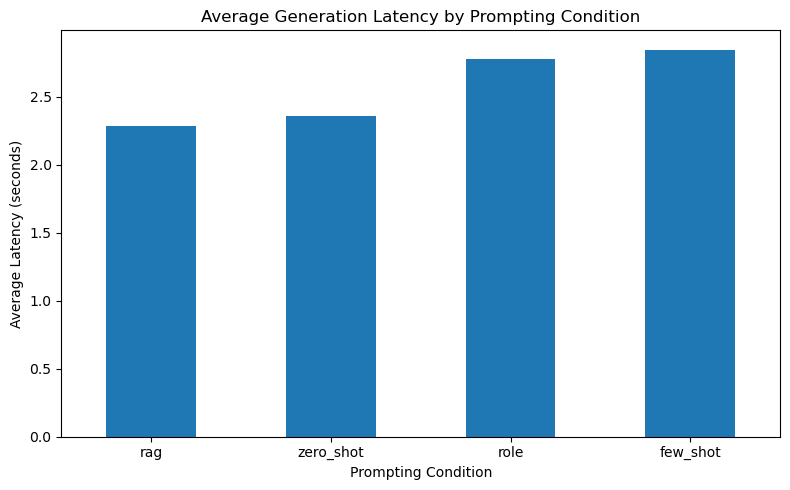

In [22]:
# average latency by prompting condition

latency = (
    analysis_df
    .groupby("condition")["latency_seconds"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
latency.plot(kind="bar")

plt.title("Average Generation Latency by Prompting Condition")
plt.xlabel("Prompting Condition")
plt.ylabel("Average Latency (seconds)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

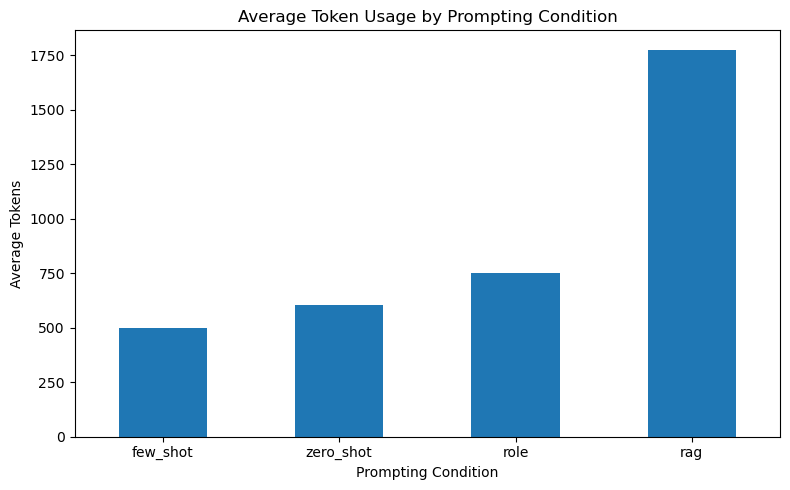

In [23]:
# average token usage by prompting condition

token_col = "tokens_used"

tokens = (
    analysis_df
    .groupby("condition")[token_col]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
tokens.plot(kind="bar")

plt.title("Average Token Usage by Prompting Condition")
plt.xlabel("Prompting Condition")
plt.ylabel("Average Tokens")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

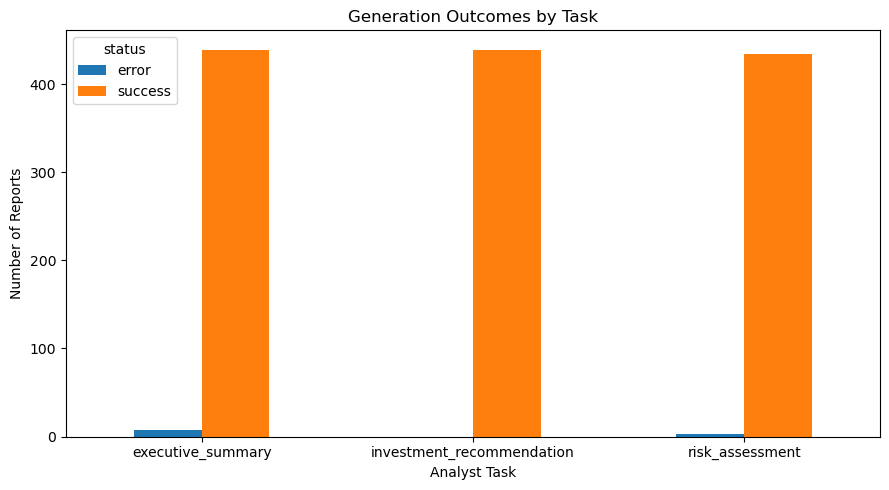

status                     error  success
task                                     
executive_summary              7      439
investment_recommendation      0      439
risk_assessment                3      434


In [24]:
# generation outcomes by task
# note: this uses results_df, not final_df, because final_df only
# contains successful rows after the Step 15 cleanup. results_df still
# has the skipped and error rows we need to show this chart properly.

status_summary = (
    results_df
    .groupby(["task", "status"])
    .size()
    .unstack(fill_value=0)
)

status_summary.plot(kind="bar", figsize=(9, 5))

plt.title("Generation Outcomes by Task")
plt.xlabel("Analyst Task")
plt.ylabel("Number of Reports")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(status_summary)

In [25]:
# summary table

summary = pd.DataFrame({
    "Successful Reports": [len(analysis_df)],
    "Average Latency (s)": [analysis_df["latency_seconds"].mean()],
    "Average Tokens": [analysis_df[token_col].mean()],
})

summary

,Successful Reports,Average Latency (s),Average Tokens
0,1312,2.571352,902.737043


#### Interpretation

The performance analysis shows that the pipeline ran consistently across all four prompting conditions.

Some points worth noting:

- RAG usually takes a bit longer than the other conditions, because it has an extra step where it retrieves narrative text before generating the report.
- Conditions that include retrieved SEC text tend to use more tokens, since extra context is being passed to the model.
- For 5 company-years, the RAG condition was skipped for Risk Assessment specifically, because no Section 1A (Risk Factors) text was available to retrieve. Zero-shot, Few-shot, and Role conditions still ran normally for these same company-years, since they do not depend on retrieval.

Overall, these results show that the pipeline is stable and reproducible across conditions, and that the exclusion rule for missing Section 1A data worked exactly as intended.

## Conclusion

This notebook generated financial analysis reports for three analyst
tasks and four prompting conditions. We used structured financial numbers
(from Member 1) in every condition, and company-specific retrieved SEC
text (from Notebooks 3 to 5) only in the RAG condition.

Two data problems found in Notebook 3, the missing APTV 2017 filing and
five company-years with an empty Risk Factors section, were handled by
skipping RAG only where retrieval was actually impossible, instead of
skipping the whole company or task, or using a different section as a
replacement. This kept the full 110 company-year sample for the Zero-shot,
Few-shot and Role conditions.

The generation batch had to run across more than one session because of
the free tier's daily limit. We used a resume system (Step 11) so no
finished work was lost between sessions. Old leftover records from
earlier debugging sessions were removed (Step 15), and one answer that got
cut off was found and fixed automatically with a higher token limit (Step
16). This is noted clearly as a small, one-off difference from the normal
generation process.

Every generation is saved with full detail: the prompt, the prompt
version, which chunks were retrieved and how many, the structured numbers
used, the response, the finish reason, latency, and tokens used. This
gives Member 3 a final, clean dataset (`generated_reports_final.parquet`,
1,312 rows) to use for evaluation, including checking generated claims
against the structured and narrative source data.

One idea from peer review that we did not use yet: adding the company
name and fiscal year as their own separate field at the start of the
prompt, instead of inside the first line of the financial numbers block.
We decided not to make this change after the full batch was already
generated, because changing the prompt wording partway through would
break the fair comparison between conditions. This is noted as a possible
improvement for future work.